10.450583572185572
5.573526022256971
C - P          = 4.877058
S - K·exp(-rT) = 4.877058
Parity holds:    True


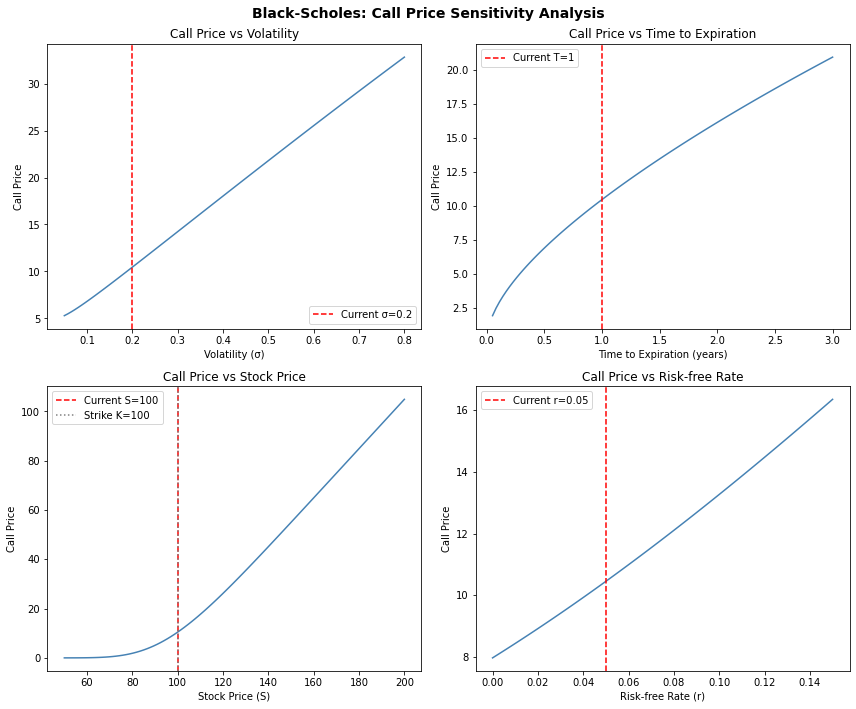

In [1]:
import numpy as np
import pandas as pd
import math
import scipy.stats as stats
import matplotlib.pyplot as plt
import Black_Scholes as BS

In [2]:
## Delta
# sensitivity of option price to price of underlying
# delta = N(d1) : call
# delta = N(d1) - 1 : put
# delta(Call) - delta(put) = 1
# here delta is delat for call

def calculateDelta(stockPrice, exercisePrice, rateOfReturn, timeToExpiration, sigma):
    d1 = BS.calculateD1(stockPrice, exercisePrice, rateOfReturn, timeToExpiration, sigma)
    
    return stats.norm.cdf(d1)

In [3]:
## Gamma
# sensitivity of option price to delta
# delta = N'(d1) / (s * sigma * sqrt(T))      {N'(): pdf }

def calculateGamma(stockPrice, exercisePrice, rateOfReturn, timeToExpiration, sigma):
    d1 = BS.calculateD1(stockPrice, exercisePrice, rateOfReturn, timeToExpiration, sigma)
    numerator = stats.norm.pdf(d1)
    denominator = stockPrice * sigma * math.sqrt(timeToExpiration)
    
    return numerator / denominator

In [4]:
## Vega
# sensitivity of option price to volatility
# vega = S * N'(d1) * sqrt(T)

def calculateVega(stockPrice, exercisePrice, rateOfReturn, timeToExpiration, sigma):
    d1 = BS.calculateD1(stockPrice, exercisePrice, rateOfReturn, timeToExpiration, sigma)
    
    return stockPrice * stats.norm.pdf(d1) * math.sqrt(timeToExpiration)

In [5]:
## Theta
# sensitivity of option price to expiration time
# theta = - (S * N'(d1) * sigma) / 2 * sqrt(T) - r * K * exp(-r * T) * N(d2) : call
# theta = - (S * N'(d1) * sigma) / 2 * sqrt(T) + r * K * exp(-r * T) * N(-d2) : put

def calculateTheta(stockPrice, exercisePrice, rateOfReturn, timeToExpiration, sigma, call):
    d1 = BS.calculateD1(stockPrice, exercisePrice, rateOfReturn, timeToExpiration, sigma)
    d2 = BS.calculateD2(sigma, timeToExpiration, d1)
    num1 = (stockPrice * stats.norm.pdf(d1) * sigma) / (2 * math.sqrt(timeToExpiration))
    num2 = (rateOfReturn * exercisePrice * math.exp(-1 * rateOfReturn * timeToExpiration))
    
    if(call):
        return -1 * (num1 + num2 * stats.norm.cdf(d2))
    else:
        return -1 * (num1 - num2 * stats.norm.cdf(-1 * d2))

In [6]:
# parameters
S = 100
K = 100
r = 0.05
sigma = 0.20
T = 1

delta = calculateDelta(S, K, r, T, sigma)

print(delta)

0.6368306511756191


In [7]:
greeksDf = pd.DataFrame(columns=['Stock Price', 'Delta', 'Gamma', 'Vega', 'Theta'])

stockPrice = np.arange(1, 201)
greeksDf['Stock Price'] = stockPrice

greeksDf['Delta'] = greeksDf['Stock Price'].apply(calculateDelta, args=(K, r, T, sigma))
greeksDf['Gamma'] = greeksDf['Stock Price'].apply(calculateGamma, args=(K, r, T, sigma))
greeksDf['Vega']  = greeksDf['Stock Price'].apply(calculateVega,  args=(K, r, T, sigma))
greeksDf['Theta'] = greeksDf['Stock Price'].apply(calculateTheta, args=(K, r, T, sigma, True))

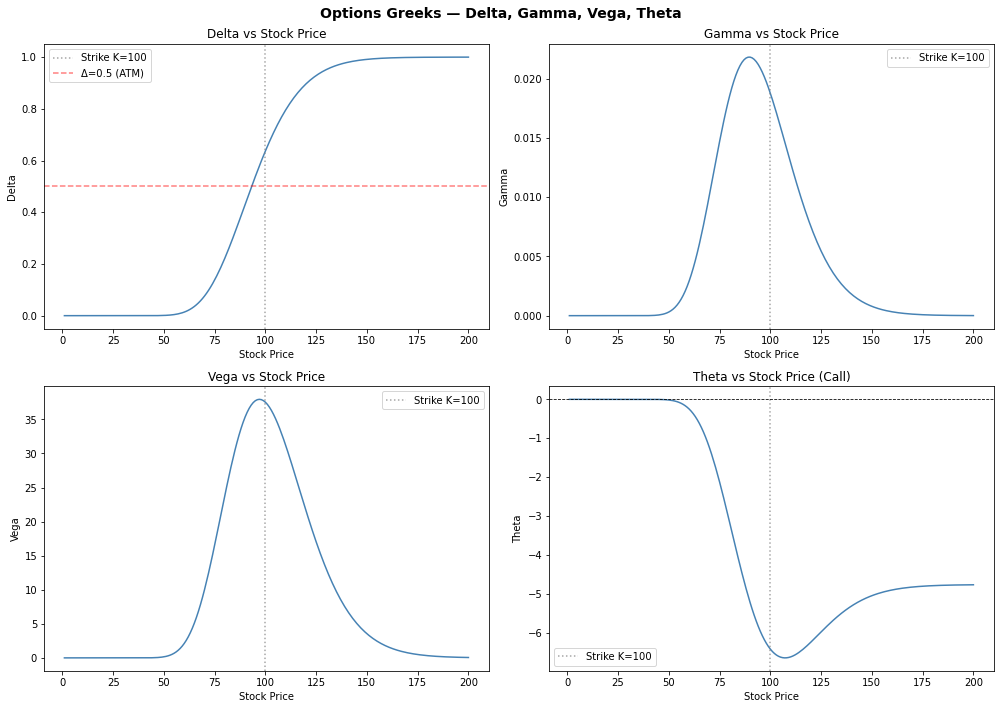

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(greeksDf['Stock Price'], greeksDf['Delta'], color='steelblue')
axes[0, 0].axvline(K, color='gray', linestyle=':', alpha=0.7, label=f'Strike K={K}')
axes[0, 0].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Δ=0.5 (ATM)')
axes[0, 0].set_title('Delta vs Stock Price')
axes[0, 0].set_xlabel('Stock Price')
axes[0, 0].set_ylabel('Delta')
axes[0, 0].legend()

axes[0, 1].plot(greeksDf['Stock Price'], greeksDf['Gamma'], color='steelblue')
axes[0, 1].axvline(K, color='gray', linestyle=':', alpha=0.7, label=f'Strike K={K}')
axes[0, 1].set_title('Gamma vs Stock Price')
axes[0, 1].set_xlabel('Stock Price')
axes[0, 1].set_ylabel('Gamma')
axes[0, 1].legend()

axes[1, 0].plot(greeksDf['Stock Price'], greeksDf['Vega'], color='steelblue')
axes[1, 0].axvline(K, color='gray', linestyle=':', alpha=0.7, label=f'Strike K={K}')
axes[1, 0].set_title('Vega vs Stock Price')
axes[1, 0].set_xlabel('Stock Price')
axes[1, 0].set_ylabel('Vega')
axes[1, 0].legend()

axes[1, 1].plot(greeksDf['Stock Price'], greeksDf['Theta'], color='steelblue')
axes[1, 1].axvline(K, color='gray', linestyle=':', alpha=0.7, label=f'Strike K={K}')
axes[1, 1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1, 1].set_title('Theta vs Stock Price (Call)')
axes[1, 1].set_xlabel('Stock Price')
axes[1, 1].set_ylabel('Theta')
axes[1, 1].legend()

plt.suptitle('Options Greeks — Delta, Gamma, Vega, Theta', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

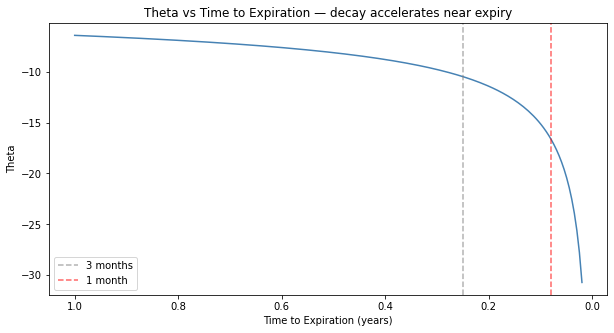

In [10]:
# Theta acceleration as expiration approaches
times = np.linspace(0.02, 1.0, 200)
theta_vs_t = [calculateTheta(S, K, r, t, sigma, call=True) for t in times]

plt.figure(figsize=(10, 5))
plt.plot(times, theta_vs_t, color='steelblue')
plt.axvline(0.25, color='gray', linestyle='--', alpha=0.6, label='3 months')
plt.axvline(0.08, color='red',  linestyle='--', alpha=0.6, label='1 month')
plt.gca().invert_xaxis()   # right = far from expiry, left = near expiry
plt.title('Theta vs Time to Expiration — decay accelerates near expiry')
plt.xlabel('Time to Expiration (years)')
plt.ylabel('Theta')
plt.legend()
plt.show()